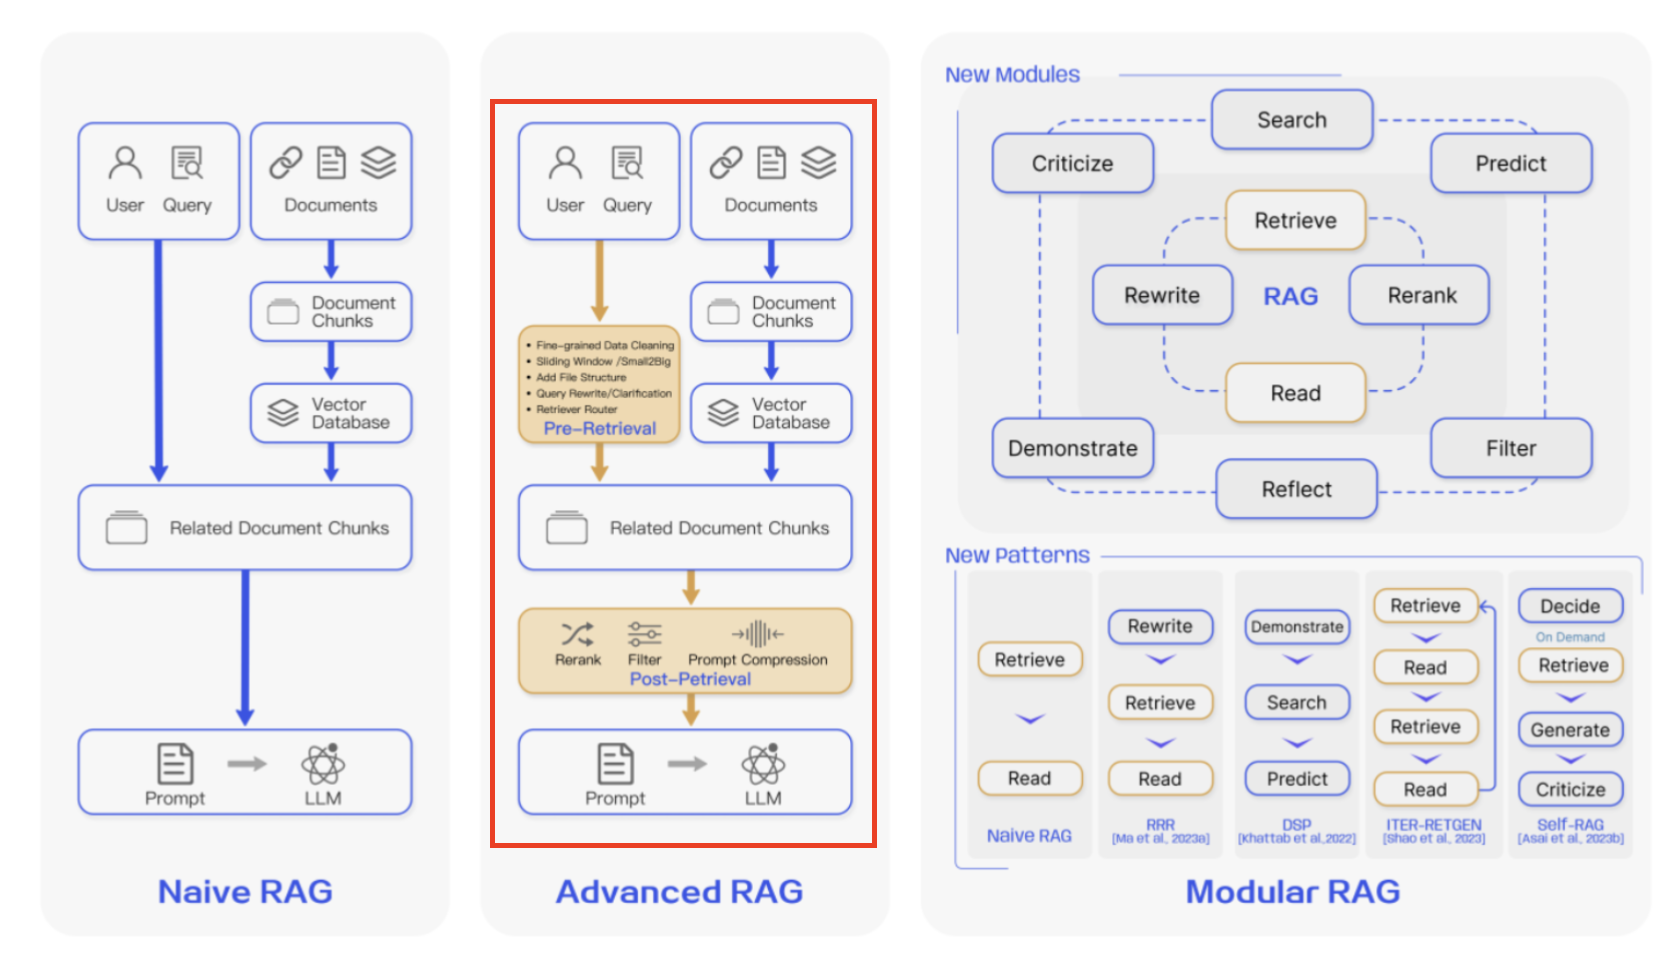

# [Adaptive RAG란?](https://www.machinelearningplus.com/gen-ai/adaptive-rag-ultimate-guide-to-dynamic-retrieval-augmented-generation/)
Adaptive RAG는 질문의 특성과 복잡도에 따라 **적응적으로** 다른 검색 전략을 사용하는 고급 RAG 기법입니다.


## 주요 개념

1. **질문 분류**: 질문의 복잡도와 유형을 분석
2. **동적 라우팅**: 질문 유형에 따라 적절한 retrieval 전략 선택
3. **Multi-Query Retrieval**: 복잡한 질문을 여러 하위 질문으로 분해하여 검색
4. **신뢰도 기반 응답**: 검색 결과의 신뢰도에 따라 답변 생성

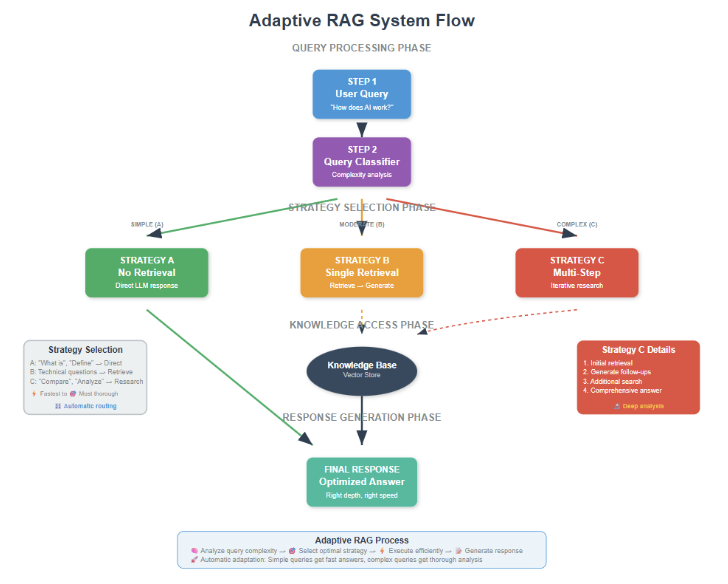

## Vector Store


### Embedding Model
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [OpenAI 요금](https://openai.com/api/pricing/)

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")


### Qdrant VectorStore

In [3]:
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore(
    client=QdrantClient(host="localhost", port=6333),
    collection_name="rag_keywords",
    embedding=embeddings_model,
)

In [4]:
results = vectorstore.similarity_search("TF IDF 에 대하여 알려줘", k=3)

for i, doc in enumerate(results, 1):
    print(f"{i}. {doc.page_content}")
    print(f"   메타데이터: {doc.metadata}")
    print()

1. 정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝

Deep Learning
   메타데이터: {'source': 'data/rag-keywords.txt', '_id': 'b6fe1032-6dda-4f2a-9afd-463204179c40', '_collection_name': 'rag_keywords'}

2. JSON

정의: JSON(JavaScript Object Notation)은 경량의 데이터 교환 형식으로, 사람과 기계 모두에게 읽기 쉬운 텍스트를 사용하여 데이터 객체를 표현합니다.
예시: {"이름": "홍길동", "나이": 30, "직업": "개발자"}는 JSON 형식의 데이터입니다.
연관키워드: 데이터 교환, 웹 개발, API

Transformer
   메타데이터: {'source': 'data/rag-keywords.txt', '_id': '672847d2-760b-4219-8e73-45321364baa5', '_collection_name': 'rag_keywords'}

3. DataFrame

정의: DataFrame은 행과 열로 이루어진 테이블 형태의 데이터 구조로, 주로 데이터 분석 및 처리에 사용됩니다.
예시: 판다스 라이브러리에서 DataFrame은 다양한 데이터 타입의 열을 가질 수 있으며, 데이터 조작과 분석을 용이하게 합니다.
연관키워드: 데이터 분석, 판다스, 데이터 처리

Attention 메커니즘
   메타데이터: {'source': 'data/rag-keywords.txt', '_id': 'ef10b0a6-ad1a-4d46-a32b-014530fadb22', '_collection_name': 'rag_keywords'}



## Adaptive RAG 구현

### 질문 분류기 구현

질문의 복잡도를 분석하여 적절한 retrieval 전략을 선택합니다.


> LLM 초기화

In [5]:
from langchain_openai import ChatOpenAI

# LLM 초기화
llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


> 질문 분류 프롬프트

In [9]:
from langchain_core.prompts import ChatPromptTemplate

# 질문 분류 프롬프트
classification_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """
        당신은 질문을 분석하는 전문가입니다. 
        주어진 질문을 분석하여 다음 중 하나로 분류하세요:

        1. SIMPLE: 단순하고 직접적인 질문 (예: "임베딩이란?", "Token의 정의는?")
        2. COMPLEX: 복잡하거나 다면적인 질문 (예: "임베딩과 벡터스토어의 관계는?", "RAG 시스템의 전체 구조를 설명해줘")
        3. OUT_OF_SCOPE: RAG, NLP, AI, 데이터 관련이 아닌 질문

        반드시 SIMPLE, COMPLEX, OUT_OF_SCOPE 중 하나만 출력하세요."""),
    ("human", "{question}")
])


> 질문 분류 체인

In [10]:
from langchain_core.output_parsers import StrOutputParser

# 질문 분류 체인
classification_chain = classification_prompt | llm | StrOutputParser()


> 테스트

In [11]:
# 테스트
test_questions = [
    "임베딩이란 무엇인가요?",
    "Semantic Search와 Keyword Search의 차이점과 각각의 장단점을 비교해주세요",
    "오늘 저녁 메뉴 추천해줘"
]

print("=== 질문 분류 테스트 ===\n")
for q in test_questions:
    category = classification_chain.invoke({"question": q})
    print(f"질문: {q}")
    print(f"분류: {category}\n")


=== 질문 분류 테스트 ===

질문: 임베딩이란 무엇인가요?
분류: SIMPLE

질문: Semantic Search와 Keyword Search의 차이점과 각각의 장단점을 비교해주세요
분류: COMPLEX

질문: 오늘 저녁 메뉴 추천해줘
분류: OUT_OF_SCOPE



### MultiQueryRetriever 설정

복잡한 질문을 여러 개의 하위 질문으로 분해하여 더 포괄적인 검색을 수행합니다.


> 기본 retriever 생성

In [12]:
# 기본 retriever 생성
base_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)


> MultiQuery 생성

In [13]:
from langchain_core.prompts import PromptTemplate

query_generation_prompt = PromptTemplate(
    input_variables=["question"],
    template="""
        당신은 AI 언어 모델 어시스턴트입니다. 
        벡터 데이터베이스에서 관련 문서를 검색하기 위해 주어진 사용자 질문을 3가지 다른 버전으로 생성하는 것이 당신의 임무입니다.
        사용자 질문에 대해 여러 관점을 생성함으로써, 거리 기반 유사도 검색의 일부 한계를 극복하는 것이 목표입니다.

        이러한 대안 질문들을 줄바꿈으로 구분하여 제공하세요.

        원본 질문: {question}

        대안 질문들:"""
)

In [14]:
from langchain_core.output_parsers import StrOutputParser

query_generation_chain = query_generation_prompt | llm | StrOutputParser()

In [15]:
result = query_generation_chain.invoke({
    "question":"임베딩이란 무엇인가요?"
})

In [16]:
print(result)

임베딩이란 무엇이며 데이터를 벡터 공간으로 표현하는 기본 아이디어는 무엇인가요?

임베딩의 목적은 무엇이고 벡터 표현이 정보 검색이나 머신러닝에서 어떤 이점을 제공하나요?

임베딩의 대표적인 유형과 알고리즘은 어떤 것이며 텍스트, 이미지, 그래프 등 다양한 데이터에 어떻게 적용되나요?


> MultiQueryRetriever 생성

In [17]:
# 입력 정규화 함수
def normalize_input(input_data):
    """입력을 문자열로 정규화"""
    if isinstance(input_data, str):
        return input_data
    elif isinstance(input_data, dict):
        return input_data.get("input") or input_data.get("question") or str(input_data)
    else:
        return str(input_data)

In [18]:
# 원본 질문과 생성된 쿼리를 합치는 함수
def add_original_query(data: dict) -> dict:
    """원본 질문을 쿼리 리스트에 추가"""
    original = data.get("question", "")
    queries = data.get("queries", [])
    # 원본 질문을 맨 앞에 추가
    all_queries = [original] + queries
    return {"all_queries": all_queries}

In [19]:
# 각 쿼리로 문서를 검색하고 중복 제거하는 함수
def retrieve_and_deduplicate(data: dict) -> list:
    """모든 쿼리로 검색 후 중복 제거"""
    queries = data.get("all_queries", [])
    all_documents = []
    seen_contents = set()
    
    for i, query in enumerate(queries, 1):
        try:
            print(f"  [쿼리 {i}/{len(queries)}] 검색 중: {query[:50]}...")
            docs = base_retriever.invoke(query)
            
            # 중복 제거
            for doc in docs:
                content = doc.page_content
                if content not in seen_contents:
                    seen_contents.add(content)
                    all_documents.append(doc)
        except Exception as e:
            print(f"  [경고] 쿼리 '{query[:50]}...' 검색 실패: {type(e).__name__}: {e}")
            # 에러가 발생해도 다른 쿼리는 계속 시도
            continue
    
    return all_documents

In [20]:
from langchain_core.runnables import RunnableLambda

multi_query_retriever = (
    # 입력 정규화
    RunnableLambda(normalize_input)
    # 쿼리 생성
    | RunnableLambda(lambda question: {
        "question": question,
        "generated_output": query_generation_chain.invoke({"question": question})
    })
    # 생성된 쿼리를 파싱
    | RunnableLambda(lambda x: {
        "question": x["question"],
        "queries": [q.strip() for q in x["generated_output"].strip().split('\n') if q.strip()]
    })
    # 원본 질문 추가
    | RunnableLambda(add_original_query)
    # 검색 및 중복 제거
    | RunnableLambda(retrieve_and_deduplicate)
)

> MultiQueryRetriever 테스트

In [21]:
# MultiQueryRetriever 테스트
test_query = "Semantic Search와 Keyword Search의 차이는?"
print(f"질문: {test_query}\n")

try:
    results = multi_query_retriever.invoke(input=test_query)
    print(f"\n검색된 문서 수: {len(results)}")
    for i, doc in enumerate(results, 1):
        print(f"\n[문서 {i}] {doc.page_content[:150]}")
except Exception as e:
    print(f"\n[에러 발생] {type(e).__name__}: {e}")


질문: Semantic Search와 Keyword Search의 차이는?

  [쿼리 1/5] 검색 중: Semantic Search와 Keyword Search의 차이는?...
  [쿼리 2/5] 검색 중: 대안 질문들:...
  [쿼리 3/5] 검색 중: Semantic Search와 Keyword Search의 차이를 벡터 데이터베이스 관점에...
  [쿼리 4/5] 검색 중: 동의어 처리와 맥락 이해가 중요한 상황에서 Semantic Search와 Keyword S...
  [쿼리 5/5] 검색 중: 두 접근법의 한계가 만나는 지점에서, 벡터 검색을 사용할 때 Semantic Search와...

검색된 문서 수: 7

[문서 1] Semantic Search

정의: 의미론적 검색은 사용자의 질의를 단순한 키워드 매칭을 넘어서 그 의미를 파악하여 관련된 결과를 반환하는 검색 방식입니다.
예시: 사용자가 "태양계 행성"이라고 검색하면, "목성", "화성" 등과 같이 관련된 행성에 대한 정보를 반환

[문서 2] Keyword Search

정의: 키워드 검색은 사용자가 입력한 키워드를 기반으로 정보를 찾는 과정입니다. 이는 대부분의 검색 엔진과 데이터베이스 시스템에서 기본적인 검색 방식으로 사용됩니다.
예시: 사용자가 "커피숍 서울"이라고 검색하면, 관련된 커피숍 목록을 반환

[문서 3] 정의: SEO는 검색 엔진에서 웹사이트의 순위를 높이기 위한 최적화 기법입니다. 검색 결과에서 더 높은 순위를 얻어 자연스러운 트래픽을 증가시킵니다.
예시: 웹 페이지의 메타 태그를 최적화하고, 의미 있는 URL 구조를 사용하여 검색 엔진이 콘텐츠를 더 잘 이해하도록 

[문서 4] 정의: HTTPS는 HTTP의 보안 버전으로, SSL/TLS 암호화를 사용하여 데이터 전송의 보안을 보장합니다. 민감한 정보를 안전하게 전송할 수 있게 해줍니다.
예시: 온라인 쇼핑몰에서 결제 정보를 입력할 때 HTTPS를 사용하여 데이터가 암호화되어 전송됩니다.
연관

[문서 5] 정

### Adaptive RAG 체인 구현

LCEL을 사용하여 질문 유형에 따라 적응적으로 동작하는 RAG 체인을 구현합니다.


> 적응적 retriever 함수

In [22]:
# 적응적 retriever 함수
def adaptive_retriever(input_dict):
    """질문 유형에 따라 적절한 retriever를 선택"""
    question = input_dict["question"]
    category = input_dict["category"]
    
    print(f"\n[Adaptive RAG] 질문 분류: {category}")
    
    if category == "OUT_OF_SCOPE":
        # 범위 밖 질문은 빈 문서 반환
        return []
    elif category == "SIMPLE":
        # 단순 질문은 기본 retriever 사용
        print("[Adaptive RAG] 전략: 기본 검색")
        return base_retriever.invoke(question)
    else:  # COMPLEX
        # 복잡한 질문은 MultiQueryRetriever 사용
        print("[Adaptive RAG] 전략: 다중 쿼리 검색")
        return multi_query_retriever.invoke(question)


> 문서 포맷팅 함수 (출처 포함)

In [23]:
# 문서 포맷팅 함수 (출처 포함)
def format_docs(docs):
    """검색된 문서를 포맷팅하고 출처 정보 추가"""
    if not docs:
        return "관련 문서를 찾을 수 없습니다.", []
    
    formatted_texts = []
    sources = []
    
    for i, doc in enumerate(docs, 1):
        title = doc.metadata.get("title", "Unknown")
        source = doc.metadata.get("source", "Unknown")
        formatted_texts.append(f"[문서 {i}: {title}]\n{doc.page_content}")
        sources.append(source)
    
    return "\n\n".join(formatted_texts), list(set(sources))  # 중복 제거


> RAG 프롬프트

In [24]:
# RAG 프롬프트
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """
        당신은 RAG, NLP, AI 관련 질문에 답변하는 전문 어시스턴트입니다.

        다음 규칙을 따르세요:
        1. 제공된 컨텍스트만을 기반으로 답변하세요.
        2. 컨텍스트에 관련 정보가 없으면 "죄송하지만, 제공된 정보에서는 해당 질문에 대한 답을 찾을 수 없습니다."라고 답변하세요.
        3. 답변은 명확하고 간결하게 작성하세요.
        4. 예시가 있다면 함께 설명해주세요.

        컨텍스트:
        {context}"""),
    ("human", "{question}")
])


> 답변에 출처 추가 함수

In [25]:
# 답변에 출처 추가 함수
def add_sources(response_dict):
    """답변에 출처 정보 추가"""
    answer = response_dict["answer"]
    sources = response_dict["sources"]
    
    # 출처가 없거나, Unknown만 있거나, 답변이 "찾을 수 없습니다"를 포함하면 출처 추가 안함
    if not sources or sources == ["Unknown"] or "찾을 수 없습니다" in answer:
        return answer
    
    # Unknown을 제외한 실제 출처만 필터링
    valid_sources = [s for s in sources if s != "Unknown"]
    if not valid_sources:
        return answer
    
    source_text = "\n\n---\n**출처:**\n" + "\n".join([f"- {source}" for source in valid_sources])
    return answer + source_text

print("Adaptive RAG 함수 정의 완료!")


Adaptive RAG 함수 정의 완료!


> LCEL을 사용한 Adaptive RAG 체인 구성

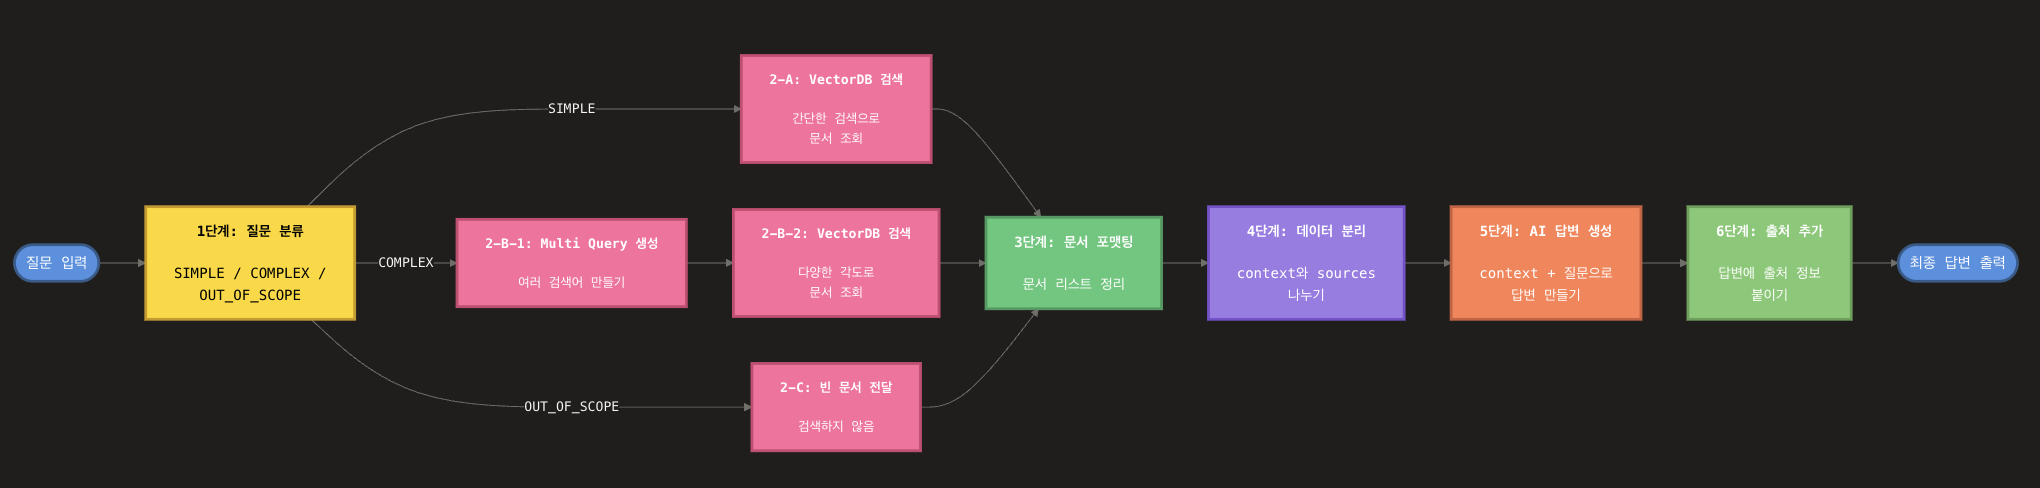

In [26]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# LCEL을 사용한 Adaptive RAG 체인 구성
adaptive_rag_chain = (
    # 1단계: 질문 분류
    {
        "question": RunnablePassthrough(),
        "category": classification_chain
    }
    # 2단계: 적응적 retrieval
    | RunnablePassthrough.assign(
        docs=RunnableLambda(adaptive_retriever)
    )
    # 3단계: 문서 포맷팅 및 출처 추출
    | RunnablePassthrough.assign(
        formatted=lambda x: format_docs(x["docs"])
    )
    # 4단계: context와 sources 분리
    | RunnablePassthrough.assign(
        context=lambda x: x["formatted"][0],
        sources=lambda x: x["formatted"][1]
    )
    # 5단계: RAG 답변 생성
    | RunnablePassthrough.assign(
        answer=(
            {
                "context": lambda x: x["context"],
                "question": lambda x: x["question"]
            }
            | rag_prompt
            | llm
            | StrOutputParser()
        )
    )
    # 6단계: 출처 추가
    | RunnableLambda(add_sources)
)

print("Adaptive RAG 체인 구성 완료!")


Adaptive RAG 체인 구성 완료!


### Adaptive RAG 테스트

다양한 유형의 질문으로 Adaptive RAG 시스템을 테스트합니다.


> 테스트 케이스 1: 단순 질문

In [27]:
# 테스트 케이스 1: 단순 질문
print("=" * 80)
print("테스트 1: 단순 질문")
print("=" * 80)

question1 = "임베딩이란 무엇인가요?"
response1 = adaptive_rag_chain.invoke(question1)
print(f"\n질문: {question1}")
print(f"\n답변:\n{response1}")


테스트 1: 단순 질문

[Adaptive RAG] 질문 분류: SIMPLE
[Adaptive RAG] 전략: 기본 검색

질문: 임베딩이란 무엇인가요?

답변:
임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡터로 변환하는 과정입니다. 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다. 예시: "사과"를 [0.65, -0.23, 0.17]와 같은 벡터로 표현합니다. 연관키워드: 자연어 처리, 벡터화, 딥러닝.

---
**출처:**
- data/rag-keywords.txt


> 테스트 케이스 2: 복잡한 질문

In [28]:
# 테스트 케이스 2: 복잡한 질문
print("\n\n" + "=" * 80)
print("테스트 2: 복잡한 질문")
print("=" * 80)

question2 = "Semantic Search와 Keyword Search의 차이점을 비교하고, 각각 어떤 상황에서 사용하면 좋을지 설명해주세요."
response2 = adaptive_rag_chain.invoke(question2)
print(f"\n질문: {question2}")
print(f"\n답변:\n{response2}")




테스트 2: 복잡한 질문

[Adaptive RAG] 질문 분류: COMPLEX
[Adaptive RAG] 전략: 다중 쿼리 검색
  [쿼리 1/4] 검색 중: Semantic Search와 Keyword Search의 차이점을 비교하고, 각각 어떤 ...
  [쿼리 2/4] 검색 중: Semantic Search와 Keyword Search의 차이점을 이론적으로 비교하고, ...
  [쿼리 3/4] 검색 중: 대규모 문서 컬렉션에서 데이터 특성(동의어, 다의어, 용어 다양성)과 사용자 의도에 따라 ...
  [쿼리 4/4] 검색 중: Semantic Search와 Keyword Search를 하나의 하이브리드 검색 전략으로...

질문: Semantic Search와 Keyword Search의 차이점을 비교하고, 각각 어떤 상황에서 사용하면 좋을지 설명해주세요.

답변:
다음과 같이 차이점과 사용 상황을 정리해볼 수 있습니다.

차이점
- 의미 이해 여부
  - Semantic Search: 사용자의 질의의 의미를 파악하여 관련된 결과를 반환하는 검색 방식입니다.
  - Keyword Search: 사용자가 입력한 키워드를 기반으로 정보를 찾는 과정입니다.
- 결과의 성격
  - Semantic Search: 질의의 의미를 이해해 넓은 맥락의 관련 정보들을 반환합니다.
  - Keyword Search: 입력된 키워드와 정확히 일치하거나 키워드 매칭이 되는 정보를 우선적으로 반환합니다.
- 일반적 사용 맥락
  - Semantic Search: 의미를 이해하고 연결된 정보를 찾고자 할 때 유용합니다.
  - Keyword Search: 기본적이고 직관적인 검색이 필요할 때 유용합니다.

예시를 통한 차이
- Semantic Search 예시: 사용자가 "태양계 행성"이라고 검색하면, 관련된 행성에 대한 정보를 반환합니다(예: 목성, 화성 등).
- Keyword Search 예시: 사용자가 "커피숍 서울"이라고 검색하면, 서울에 위치한 커피숍 목록이 반

> 테스트 케이스 3: 범위 밖 질문

In [29]:
# 테스트 케이스 3: 범위 밖 질문
print("\n\n" + "=" * 80)
print("테스트 3: 범위 밖 질문")
print("=" * 80)

question3 = "오늘 저녁 메뉴로 뭐가 좋을까요?"
response3 = adaptive_rag_chain.invoke(question3)
print(f"\n질문: {question3}")
print(f"\n답변:\n{response3}")




테스트 3: 범위 밖 질문

[Adaptive RAG] 질문 분류: OUT_OF_SCOPE

질문: 오늘 저녁 메뉴로 뭐가 좋을까요?

답변:
죄송하지만, 제공된 정보에서는 해당 질문에 대한 답을 찾을 수 없습니다.


> 테스트 케이스 4: 데이터베이스에 없는 내용에 대한 질문

In [30]:
# 테스트 케이스 4: 데이터베이스에 없는 내용에 대한 질문
print("\n\n" + "=" * 80)
print("테스트 4: 데이터베이스에 없는 RAG 관련 질문")
print("=" * 80)

question4 = "Quantum Computing과 RAG의 관계는?"
response4 = adaptive_rag_chain.invoke(question4)
print(f"\n질문: {question4}")
print(f"\n답변:\n{response4}")




테스트 4: 데이터베이스에 없는 RAG 관련 질문

[Adaptive RAG] 질문 분류: COMPLEX
[Adaptive RAG] 전략: 다중 쿼리 검색
  [쿼리 1/5] 검색 중: Quantum Computing과 RAG의 관계는?...
  [쿼리 2/5] 검색 중: 대안 질문들:...
  [쿼리 3/5] 검색 중: Quantum Computing과 RAG의 관계를 개념적으로 설명해 주세요. 양자 기술이 ...
  [쿼리 4/5] 검색 중: RAG와 양자 컴퓨팅의 시너지는 어떤 방식으로 나타날 수 있나요? 벡터 검색, 데이터 인덱...
  [쿼리 5/5] 검색 중: 양자 컴퓨팅 관점에서 본 RAG 구현의 설계 패턴은 어떤 것들이 있으며, 현재 기술 수준의...

질문: Quantum Computing과 RAG의 관계는?

답변:
죄송하지만, 제공된 정보에서는 해당 질문에 대한 답을 찾을 수 없습니다.
